# Aula 05 - Matriz de Diferenciação via Jacobi

No último encontro (Aula 04), nós conseguimos um grande feito: construímos a **Matriz de Diferenciação** ($\mathcal{D}_r$) utilizando a Matriz de Vandermonde Generalizada. 

A abordagem de Hesthaven e Warburton que utilizamos é extremamente elegante do ponto de vista da Álgebra Linear. Nós usamos a Vandermonde para "traduzir" os valores físicos para o mundo espectral, calculamos as derivadas lá, e trouxemos de volta. O computador fez todo o trabalho pesado invertendo e multiplicando matrizes ($\mathcal{D}_r = \mathcal{V}_r \mathcal{V}^{-1}$).

Mas existe uma outra forma de enxergar esse problema.

A abordagem clássica de Karniadakis & Sherwin busca entender exatamente **o que está acontecendo fisicamente em cada nó da nossa malha**. Em vez de inverter matrizes de mudança de base, essa via (conhecida como Método de Colocação) constrói a Matriz de Diferenciação **analiticamente**, derivando diretamente os polinômios de Lagrange nó a nó!

Neste encontro, vamos "abrir o capô" do Polinômio Interpolador de Lagrange. O nosso objetivo é provar que, com a dose certa de cálculo (e a ajuda valiosa da Regra de L'Hôpital), podemos chegar exatamente na mesma Matriz de Diferenciação da aula passada, mas construindo suas entradas $\mathbf{D}_{ij}$ termo a termo.

###

In [1]:
from graphviz import Digraph

dot1 = Digraph()

dot1.node("A", "Espaço\nPolinomial")
dot1.node("B", "Base Modal")
dot1.node("C", "Legendre")
dot1.node("D", "Vandermonde")
dot1.node("E", "Base Nodal\n(Lagrange)")
dot1.node("F", "Matriz de\nDiferenciação")

dot1.edges([
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("D","E"),
    ("E","F")
])

dot1.attr(rankdir="LR")



dot2 = Digraph()

dot2.node("A", "Espaço\nPolinomial")
dot2.node("B", "Base Nodal")
dot2.node("C", "Interpolação de\nLagrange")
dot2.node("D", "Expansão em\nLegendre")
dot2.node("E", "Base Modal")
dot2.node("F", "Matriz de\nDiferenciação")

dot2.edges([
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("D","E"),
    ("E","F")
])

dot2.attr(rankdir="LR")

In [2]:
import os
# Adiciona a pasta padrão do Graphviz no PATH temporariamente
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'

### Warburton

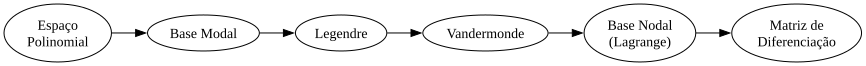

In [3]:
dot1

### Karniadakis

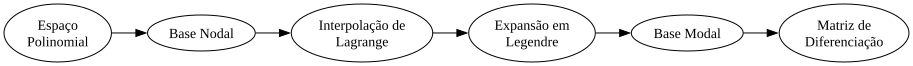

In [4]:
dot2

## Espaço Polinomial e Base Nodal

> **Nota:** O presente texto é uma tradução quase direta do livro do Karniadakis, com alguns passos matemáticos a mais.

Suponhamos que a função $u(x) \in \mathcal{P}_P$, em que $\mathcal{P}_P$ é o espaço de todos os polinômios de grau $\leq P$, que podem ser escritos em termos dos polinômios de Lagrange $\ell_i(x)$ por meio de um conjunto de $Q$ pontos nodais $x_i\ (0 \leq i \leq Q-1)$ o que segue:

$$u(x) = \sum_{i=0}^{Q-1}u(x_i)\ell_i(x)$$

em que $Q \geq P + 1$ e $\ell_i(x)$ é como vimos no encontro 04 e conforme notações desse encontro pode ser escrito como
$$\ell_i(x) = \prod_{j=0, j \neq i} ^{Q-1} \dfrac{x - x_j}{x_i - x_j}$$

No entanto, se quisermos derivar a nossa função $u(x)$ é recomendado utilizar uma outra forma para o polinômio de Lagrange e que é apresentada por Szego em 1975 ([Lagrange Interpolating Polynomial](https://mathworld.wolfram.com/LagrangeInterpolatingPolynomial.html)).

$$ {\ell_i(x) = \dfrac{\pi_Q(x)}{\pi'_Q(x_i)(x - x_i)}} $$

com $\pi_Q(x) \equiv \prod_{j=0} ^{Q-1} ({x - x_j}) $. Vamos chegar nesta representação indicada.

---
Partimos da seguinte suposição, seja o polinômio $\pi_Q(x)$ definido por
$$\pi_Q(x) \equiv \prod_{j=0} ^{Q-1} ({x - x_j}) $$

ele pode ser ainda reescrito colocando o fator de $x_i$ em evidência, isto é:
$$\pi_Q(x) = ({x - x_i})\prod_{j=0 \\j\neq i} ^{Q-1} ({x - x_j}) $$

isso implica que
$$\boxed{\frac{\pi_Q(x)}{({x - x_i})} = \prod_{j=0 \\j\neq i} ^{Q-1} ({x - x_j})} $$
Podemos, é claro, derivar esse polinômio (**veja a dedução na próxima célula**) e avaliá-lo neste mesmo ponto chegando (**veja a dedução na próxima célula**) a
$$\boxed{\pi'_Q(x_i) = \left[\dfrac{d \pi}{dx} \right]_{x = x_i} = \prod_{j=0\\j\neq i} ^{Q-1} ({x_i - x_j})} $$

Se dividirmos ambos os resultados, temos:

$$\dfrac{\frac{\pi_Q(x)}{({x - x_i})}}{\pi'_Q(x_i)} = \dfrac{\prod_{j=0,j\neq i} ^{Q-1} ({x - x_j})}{\prod_{j=0,j\neq i} ^{Q-1} ({x_i - x_j})} = \prod_{j=0, j \neq i} ^{Q-1} \dfrac{x - x_j}{x_i - x_j} = \ell_i(x)$$

Assim temos o chamado **Polinômio interpolador de Lagrange Fundamental**
$$ \boxed{\ell_i(x) = \dfrac{\pi_Q(x)}{\pi'_Q(x_i)(x - x_i)}} $$

#### Derivada de $\pi(x)$ e o valor de $\pi'(x_i)$

> **Obs:** O subindice Q foi retraído para uma apresentação mais limpa das deduções

Vamos usar a estratégia de derivada logaritmica,

**Passo 1: Expandimos**
$$\pi(x) \equiv \prod_{j=0} ^{Q-1} ({x - x_j}) = (x - x_0)(x-x_1)\cdot \ \dots \ \cdot (x-x_{Q-1}) $$

**Passo 2: Usamos o log**
$$\ln(\pi(x))  = \ln[(x - x_0)(x-x_1)\cdot \ \dots \ \cdot (x-x_{Q-1})] = \ln(x-x_0) + \ln(x-x_1) + \dots + \ln(x-x_{Q-1}) $$

**Passo 3: Derivamos**
$$\frac{\pi'(x)}{\pi(x)}  = \frac{1}{(x-x_0)} + \frac{1}{(x-x_1)} + \dots + \frac{1}{(x-x_{Q-1})} $$

**Passo 4: Isolar a derivada**
$$\frac{\pi'(x)}{\pi(x)}  = \frac{1}{(x-x_0)} + \frac{1}{(x-x_1)} + \dots + \frac{1}{(x-x_{Q-1})} ⇒ $$
$$\pi'(x) = \frac{\pi(x)}{(x-x_0)} + \frac{\pi(x)}{(x-x_1)} + \dots + \frac{\pi(x)}{(x-x_{Q-1})}  $$

Vamos avaliar um caso que Q = 3 para destacar uma evidência
$$\begin{align*}\pi'(x) = & \frac{\pi(x)}{(x-x_0)} + \frac{\pi(x)}{(x-x_1)}  + \frac{\pi(x)}{(x-x_{2})} \\
= & \frac{(x-x_{0})(x-x_{1})(x-x_{2})}{(x-x_0)} + \frac{(x-x_{0})(x-x_{1})(x-x_{2})}{(x-x_1)}  + \frac{(x-x_{0})(x-x_{1})(x-x_{2})}{(x-x_{2})} \\
= & (x-x_{1})(x-x_{2}) + (x-x_{0})(x-x_{2}) + (x-x_{0})(x-x_{1})
\end{align*}  $$

Temos uma **soma de produtos**, em que cada termo k da soma não detém o multiplicador $(x - x_{k})$ ou seja, podemos escrever
$$\boxed{\pi'(x) = \sum_{k=0}^{Q-1}\prod_{j=0 \\ j \neq k}^{Q-1}(x-x_j)}$$

---
**Observe** Se no nosso exemplo (Q = 3) escolhemos avaliar:
* $x = x_1 \Rightarrow \pi'(x_1) = ({\color{blue}x_1}-x_{1})({\color{blue}x_1}-x_{2}) + ({\color{blue}x_1}-x_{0})({\color{blue}x_1}-x_{2}) + ({\color{blue}x_1}-x_{0})({\color{blue}x_1}-x_{1}) = ({\color{blue}x_1}-x_{0})({\color{blue}x_1}-x_{2})$
* $x = x_2 \Rightarrow \pi'(x_2) = ({\color{red}x_2}-x_{1})({\color{red}x_2}-x_{2}) + ({\color{red}x_2}-x_{0})({\color{red}x_2}-x_{2}) + ({\color{red}x_2}-x_{0})({\color{red}x_2}-x_{1}) = ({\color{red}x_2}-x_{0})({\color{red}x_2}-x_{1})$

podemos concluir que, de toda a soma, só restará os produtos de termos $(x_i-x_j)$ quando $i \neq j$, ou seja

$$\boxed{\pi'(x_i) = \prod_{j=0 \\ j \neq i}^{Q-1}(x_i-x_j)}$$


### Prosseguindo com a derivada de $u(x)$

Agora que temos uma formulação mais indicada para Lagrange, podemos prosseguir com a derivada de $u(x)$. De forma geral ela é
$$\dfrac{du(x)}{dx} = \sum_{i=0}^{Q-1}u(x_i)\dfrac{d}{dx}\ell_i(x)$$

Se calculamos $du(x)/dx$ nos pontos nodais $x_i$, temos:
$$\left. \dfrac{du(x)}{dx} \right|_{x=x_i} = \sum_{i=0}^{Q-1}\mathbf{D}_{ij}u(x_j)$$

em que
$$\mathbf{D}_{ij} = \left.\dfrac{d \ell_j(x)}{dx}\right|_{x=x_i}$$

Como conseguimos escrever
$$ {\ell_i(x) = \dfrac{\pi_Q(x)}{\pi'_Q(x_i)(x - x_i)}} $$
então sua derivada é fácil de se obter
$$ \dfrac{d \ell_i(x)}{dx} = \dfrac{\pi'_Q(x)(x-x_i) - \pi_Q(x)}{\pi'_Q(x_i)(x - x_i)^2}$$

> **Nota:** Perceba que a matriz $\mathbf{D}_{ij}$ é a derivada feita no Lagrange de $j$ e avaliada no ponto $x_i$

então vamos trocar os índices para não haver confusões, a derivada de $\ell_j$ é escrita portanto como sendo:

$$ \dfrac{d \ell_j(x)}{dx} = \dfrac{\pi'_Q(x)(x-x_j) - \pi_Q(x)}{\pi'_Q(x_j)(x - x_j)^2}$$

Ao avaliar em $x_i$
$$ \left. \dfrac{d \ell_j(x)}{dx} \right|_{x=x_i} =
\dfrac{\pi'_Q(x_i)(x_i-x_j) - \pi_Q(x_i)}{\pi'_Q(x_j)(x_i - x_j)^2}$$

Note que temos duas situações a serem avaliadas, o caso $x_i = x_j$ e o caso $x_i \neq x_j$.

---
**Caso $x_i \neq x_j$**

Vamos lembrar que $\pi_Q(x)$ pode ser escrito como:
$$\pi_Q(x) = ({x - x_i})\prod_{j=0,j\neq i} ^{Q-1} ({x - x_j}) $$

e portanto $\pi_Q(x_i) = 0$, substituindo esse resultado e fazendo as devidas manipulação
$$ \left. \dfrac{d \ell_j(x)}{dx} \right|_{x=x_i} =
\dfrac{\pi'_Q(x_i)}{\pi'_Q(x_j)} \dfrac{1}{(x_i - x_j)}$$

---
**Caso $x_i = x_j$**

Note que se substituirmos diretamente teremos uma **indeterminação** pois o tanto o numerador quanto o denominador irão zerar, então é podemos aplicar o limite de quando $x_i \to x_j$ junto a regra de L'Hopital (derivando com relação a $x_i$)

$$ \lim_{x_i \to x_j} \left. \dfrac{d \ell_j(x)}{dx} \right|_{x=x_i} = \lim_{x_i \to x_j}
\dfrac{\pi'_Q(x_i){\color{red}(x_i-x_j)} - \pi_Q(x_i)}{\pi'_Q(x_j)(x_i - x_j)^2}$$

ao aplicar L'Hopital
$$ \lim_{x_i \to x_j}
\dfrac{\pi''_Q(x_i){\color{red}(x_i-x_j)} + \pi'_Q(x_i)\cdot {\color{red}1} - \pi'_Q(x_i)}{2\pi'_Q(x_j)(x_i - x_j)} = \lim_{x_i \to x_j}
\dfrac{\pi''_Q(x_i) {(x_i-x_j)}}{2\pi'_Q(x_j)(x_i - x_j)} =\lim_{x_i \to x_j}
\dfrac{\pi''_Q(x_i)}{2\pi'_Q(x_j)}$$

agora o limite pode ser de fato aplicado
$$ \left. \dfrac{d \ell_j(x)}{dx} \right|_{x=x_i} = \dfrac{\pi''_Q(x_i)}{2\pi'_Q(x_i)}$$

---

Nesse sentido temos portanto que

$$
\boxed{
\mathbf{D}_{ij} =
\begin{cases}
\dfrac{\pi'_Q(x_i)}{\pi'_Q(x_j)} \dfrac{1}{(x_i - x_j)} , & i \neq j \\
\dfrac{\pi''_Q(x_i)}{2\pi'_Q(x_i)}, & i = j
\end{cases}}
$$



Apesar de toda elegância matemática que acabamos de demonstrar, existem as ressalvas que foram apresentadas no encontro 04:

* Se mantermos o $\pi_Q$ tradicional estaremos criando uma matriz que advém de "monômios"
* Se avaliarmos a matriz em pontos equidistantes isso levará a má condição da matriz
* Note ainda que precisariámos da segunda derivada de $\pi_Q$

Por esse motivo vamos adotar estratégias via formulação de Jacobi

## Matriz de Diferenciação via Jacobi

> **Nota:** O presente texto é uma tradução quase direta do livro do Karniadakis, com alguns passos matemáticos a mais.

A partir de agora, encontraremos as formas específicas de $\pi'_Q(x_i)$ e $\pi''_Q(x_i)$ correspondentes aos pontos nodais da **quadratura geral de Gauss-Jacobi**. Para avaliar a
matriz de diferenciação $\mathbf{D}_{ij}$, esses valores devem ser substituídos na equação que encontramos.

Lembramos que $x_{i,m}^{\alpha,\beta}$ é definido como
$$P_{m}^{\alpha,\beta}(x_{i,m}^{\alpha,\beta}) = 0$$
em que $P_{m}^{\alpha,\beta}$ são os polinômios de Jacobi.

Vamos lembrar que das aulas 02 e 03 existem famílias diferentes de quadratura:
* Gauss-Jacobi (Gauss-Legendre) : somente pontos internos ao intervalo $[-1, 1]$
* Gauss-Radau-Jacobi : pontos internos ao intervalo $[-1, 1]$ e um ponto na fronteira (normalmente -1)
* Gauss-Lobatto-Jacobi : Considera os dois pontos da fronteira e pontos internos

Assim como anteriormente, vamos considerar o estudo somente para os pontos de Gauss-Legendre e Gauss-Lobatto





### Matriz de Diferenciação para os pontos de Gauss-Legendre

Para esse caso os nós são dados por
$$x_i = x_{i,Q}^{\alpha,\beta}$$

e então
$$
\begin{align*}
\pi_Q(x) = & P_{Q}^{\alpha,\beta}(x_i), \\
\pi'_Q(x) = & [P_{Q}^{\alpha,\beta}(x_i)]', \\
\pi''_Q(x) = & [P_{Q}^{\alpha,\beta}(x_i)]''
\end{align*}
$$

Mas vejamos, das propriedades que vimos na aula 02, se o ponto $x_i = x_{i,Q}^{\alpha,\beta}$ então
$$P_{Q}^{\alpha,\beta}(x_i) = 0$$

Na aula 01 vimos que os polinômios de Jacobi são todos aqueles que resolvem a EDO de Jacobi, sendo essa escrita na forma:

$$(1-x^2)y'' + [\beta - \alpha - (\alpha + \beta + 2)x]y' + k(k + \alpha + \beta + 1)y = 0$$

com $y(x) = P_{Q}^{\alpha,\beta}(x)$, subsituindo isso na equação anterior para ficar evidente
$$(1-x^2)[P_{Q}^{\alpha,\beta}(x)]'' + [\beta - \alpha - (\alpha + \beta + 2)x][P_{Q}^{\alpha,\beta}(x)]' + k(k + \alpha + \beta + 1)P_{Q}^{\alpha,\beta}(x) = 0$$

como queremos avaliar o ponto $x_i$
$$(1-x_i^2)[P_{Q}^{\alpha,\beta}(x_i)]'' + [\beta - \alpha - (\alpha + \beta + 2)x_i][P_{Q}^{\alpha,\beta}(x_i)]' + k(k + \alpha + \beta + 1)\underbrace{P_{Q}^{\alpha,\beta}(x_i)}_{=\,0} = 0$$
o que segue
$$(1-x_i^2)[P_{Q}^{\alpha,\beta}(x_i)]'' + [\beta - \alpha - (\alpha + \beta + 2)x_i][P_{Q}^{\alpha,\beta}(x_i)]' = 0$$

logo podemos escrever a segunda derivada em função da primeira e encontrar a relação
$$
\boxed{
  [P_{Q}^{\alpha,\beta}(x_i)]'' = \frac{\alpha - \beta + (\alpha + \beta + 2)x_i}{1-x_i^2}[P_{Q}^{\alpha,\beta}(x_i)]'
}
$$

Mas se voltarmos a definição da matriz $\mathbf{D}_{ij}$ temos
$$
\mathbf{D}_{ij} =
\begin{cases}
\dfrac{\pi'_Q(x_i)}{\pi'_Q(x_j)} \dfrac{1}{(x_i - x_j)} , & i \neq j \\
\dfrac{\pi''_Q(x_i)}{2\pi'_Q(x_i)}, & i = j
\end{cases}
$$

veja que para a diagonal $\mathbf{D}_{ii}$ conseguimos simplificar e chegar assim a
$$
\mathbf{D}_{ij} =
\begin{cases}
\dfrac{[P_{Q}^{\alpha,\beta}(x_i)]'}{[P_{Q}^{\alpha,\beta}(x_j)]'} \dfrac{1}{(x_i - x_j)} , & i \neq j \\
\dfrac{\alpha - \beta + (\alpha + \beta + 2)}{2}\dfrac{x_i}{1-x_i^2}, & i = j
\end{cases}
$$

> O valor de $[P_{Q}^{\alpha,\beta}(x_i)]'$ pode ser calculado com as relações de recorrência que ja vimos (o nosso `DJacobiP`)



### Matriz de Diferenciação para os pontos de Gauss-Lobatto

Como nesse caso os nossos nós são os dois extremos e os pontos centrais, temos que avaliar separadamente. De forma explicita têm-se que

$$
x_i = \begin{cases}
-1,  & i =& 0 \\
x_{i,Q-2}^{\alpha,\beta}, & i = & 1, \dots , Q-2\\
1, & i = & Q-1
\end{cases}
$$

como os extremos já estão sendo avaliados individualmente, a função de Jacobi deve ser ponderada nesses pontos (**a expressão deve zerar!!**) e os expoentes $(\alpha, \beta)$ deslocados em uma unidade (**isso vem das relações de ortogonalidade (ver apêndice da aula 03)**), ou seja:
$$\pi_Q(x) = (1-x)(1+x)P_{Q-2}^{\alpha+1,\beta+1}(x)$$
ao derivar uma vez em $x$
$$\pi'_Q(x) = (1-x)(1+x)[P_{Q-2}^{\alpha+1,\beta+1}(x)]' - 2xP_{Q-2}^{\alpha+1,\beta+1}(x)$$
ao derivar uma outra vez
$$\pi''_Q(x) = (1-x)(1+x)[P_{Q-2}^{\alpha+1,\beta+1}(x)]'' - 4xP_{Q-2}^{\alpha+1,\beta+1}(x)' - 2P_{Q-2}^{\alpha+1,\beta+1}(x)$$

Similar ao argumento apresentado na seção anterior, a segunda derivada se relaciona com a primeira, o termo avaliado em $(1 \leq i \leq Q-2)$ pode ser expresso por

$$(1-x_i)(1+x_i)[P_{Q-2}^{\alpha+1,\beta+1}(x_i)]'' = [\alpha - \beta + (\alpha + \beta + 4)x_i][P_{Q-2}^{\alpha+1,\beta+1}(x_i)]'$$

Portanto os valores de $\pi'_Q(x_i)$ e $\pi''_Q(x_i)$ são expressos por

$$
\pi'_Q(x_i) = \begin{cases}
\dfrac{(-1)^Q 2 \Gamma(Q+\beta)}{\Gamma(Q-1)\Gamma(\beta+2)},  & i =& 0 \\
(1-x_i)(1+x_i)[P_{Q-2}^{\alpha+1,\beta+1}(x_i)]', & i = & 1, \dots , Q-2\\
\dfrac{-2 \Gamma(Q+\alpha)}{\Gamma(Q-1)\Gamma(\alpha+2)}, & i = & Q-1
\end{cases}
$$


$$
\pi''_Q(x_i) = \begin{cases}
\dfrac{(-1)^Q 2 [\alpha - (Q-1)(Q+\alpha+\beta)]}{\beta+2} \dfrac{\Gamma(Q+\beta)}{\Gamma(Q-1)\Gamma(\beta+2)},  & i =& 0 \\
(\alpha - \beta + (\alpha + \beta)x_i)[P_{Q-2}^{\alpha+1,\beta+1}(x_i)]', & i = & 1, \dots , Q-2\\
\dfrac{2 (\beta - (Q-1)(Q+\alpha+\beta))}{\alpha+2}\dfrac{\Gamma(Q+\alpha)}{\Gamma(Q-1)\Gamma(\alpha+2)}, & i = & Q-1
\end{cases}
$$

As expressões acima podem ser obtidas utilizando as **relações especiais** apresentadas na aula 01.

> A demonstração fica a cargo do leitor 😀

Com essas expressões podemos enfim calcular a matriz de Diferenciação!!

## Condando a Matriz de Diferenciação

Abaixo vamos colocar as funções definidas ao longo das aulas 01 a 03 para nos auxiliar nessa invesigação

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

### POLINOMIOS DE JACOBI PARA ENCONTRAR DIFERENTES FAMILIAS
# alpha = 0 | beta = 0 --> Polinomios de Legendre
# alpha = -0.5 | beta = -0.5 --> Polinomios de Chebyshev normalizados
def JacobiP(r: float, m: int, alpha: float, beta: float) -> float:
    """
    Avalia o Polinômio de Jacobi de ordem m no ponto r com pesos alpha e beta.

    ### Parameters
      r (float): O ponto a ser avaliado.
      m (int): O grau do polinomio.
      alpha (float): Parâmetro associado a alguma família dos polinômios de Jacobi
      beta (float): Parâmetro associado a alguma família dos polinômios de Jacobi

    ### Returns
      float: Retorna o resultado do polinomio de Jacobi para o ponto r.

    """
    if m == 0:
        return 1.0

    pn0 = 1.0
    pn1 = 0.5 * (alpha - beta + (alpha + beta + 2.0) * r)

    if m == 1:
        return pn1

    pn2 = 0.0
    for n in range(1, m):
        a1n = 2.0 * (n + 1) * (n + alpha + beta + 1) * (2.0 * n + alpha + beta)
        a2n = (2.0 * n + alpha + beta + 1) * (alpha**2 - beta**2)
        a3n = (2.0 * n + alpha + beta) * (2.0 * n + alpha + beta + 1) * (2.0 * n + alpha + beta + 2)
        a4n = 2.0 * (n + alpha) * (n + beta) * (2.0 * n + alpha + beta + 2)

        pn2 = (1.0 / a1n) * ((a2n + a3n * r) * pn1 - a4n * pn0)
        pn0 = pn1
        pn1 = pn2

    return pn2

### DERIVADA DE ORDEM 1 DOS POLINOMIOS DE JACOBI
def DJacobiP(r: float, m: int, alpha: float, beta: float) -> float:
    """
    Primeira derivada do Polinômio de Jacobi de ordem m avaliado no ponto r.
    Utiliza math.gamma para suportar adequadamente os parâmetros fracionários
    (ex: Chebyshev, onde alpha e beta = -0.5).
    """
    if m == 0:
        return 0.0

    if np.isclose(r, -1.0):
        c1 = ((-1.0)**(m-1))*0.5*(alpha+beta+m+1)
        return c1 * (
            math.gamma(m+beta+1) /
            (math.gamma(beta+2)*math.gamma(m))
        )

    if np.isclose(r, 1.0):
        c1 = 0.5*(alpha+beta+m+1)
        return c1 * (
            math.gamma(m+alpha+1) /
            (math.gamma(alpha+2)*math.gamma(m))
        )

    # Para pontos internos, calculamos o polinômio e usamos a relação para a derivada
    Pm  = JacobiP(r, m, alpha, beta)
    Pm1 = JacobiP(r, m-1, alpha, beta)

    b1n = (2*m + alpha + beta)*(1-r**2)
    b2n = m*(alpha-beta-(2*m+alpha+beta)*r)
    b3n = 2*(m+alpha)*(m+beta)

    return (b2n*Pm + b3n*Pm1)/b1n

def jacobi_roots(m: int, alpha: float, beta: float) -> np.ndarray:
    """
    Encontra as raízes do Polinômio de Jacobi de ordem m
    usando Newton-Raphson acoplado com Deflação Polinomial.

    ### Args:
      m (int): O grau do polinomio de Jacobi.
      alpha (float): Parâmetro associado a alguma família dos polinômios de Jacobi
      beta (float): Parâmetro associado a alguma família dos polinômios de Jacobi

    ### Returns:
      array: As m-raízes do Polinomio de Jacobi de grau m
    """
    if m == 0:
        return np.array([])

    x = np.zeros(m)
    epsilon = 1.0e-16

    for k in range(m):
        # Chute inicial: raízes do polinômio de Chebyshev
        r = -np.cos(np.pi * (2.0 * k + 1.0) / (2.0 * m))
        if k > 0:
            r = 0.5 * (r + x[k - 1])

        delta = 1.0
        while abs(delta) > epsilon:
            s = 0.0
            for i in range(k):
                s += 1.0 / (r - x[i])

            pm = JacobiP(r, m, alpha, beta)
            dpm = DJacobiP(r, m, alpha, beta)

            # Relação de Newton-Raphson com Deflação
            delta = -pm / (dpm - pm * s)
            r += delta

        x[k] = r

    return x

def jacobi_gauss_weights(x: np.ndarray, alpha: float, beta: float, n_points: int, quad_type: str = 'GL') -> np.ndarray:
    """
    Calcula os pesos correspondentes para as raízes da Quadratura
    do tipo Gauss-Legendre (GL) ou Gauss-Lobatto-Legendre (GLL) baseando-se no número de pontos.

    ### Args:
      x (np.array): Vetor de pontos a serem avaliados (zeros da quadratura).
      alpha (float): Parâmetro associado a alguma família dos polinômios de Jacobi
      beta (float): Parâmetro associado a alguma família dos polinômios de Jacobi
      n_points (int): Número de pontos para a quadratura ser exata
    ### Returns:
      array: Os pesos da quadratura
    """
    w = np.zeros(n_points)

    if quad_type == 'GL':
        c1 = (2.0**(alpha + beta + 1.0)) * math.gamma(alpha + n_points + 1.0) * math.gamma(beta + n_points + 1.0)
        c2 = math.gamma(n_points + 1.0) * math.gamma(alpha + beta + n_points + 1.0)
        coef = c1 / c2

        for i in range(n_points):
            dpm = DJacobiP(x[i], n_points, alpha, beta)
            w[i] = coef / ((1.0 - x[i]**2) * (dpm**2))

    elif quad_type == 'GLL':
        c1 = (2.0**(alpha + beta + 1.0)) * math.gamma(alpha + n_points) * math.gamma(beta + n_points)
        c2 = (n_points - 1.0)* math.gamma(n_points) * math.gamma(alpha + beta + n_points + 1.0)
        coef = c1 / c2

        for i in range(n_points):
            pm_minus_1 = JacobiP(x[i], n_points - 1, alpha, beta)
            c_i = coef / (pm_minus_1**2)

            if i == 0:
                w[i] = (beta + 1.0) * c_i
            elif i == n_points - 1:
                w[i] = (alpha + 1.0) * c_i
            else:
                w[i] = c_i
    else:
        raise ValueError("Integração inválida. Escolha 'GL' ou 'GLL'.")

    return w

def jacobi_gauss_quad(P: int, alpha: float = 0.0, beta: float = 0.0, quad_type: str = 'GL'):
    """
    Retorna as matrizes de raízes (xi) e pesos (wi) garantindo exatidão
    para a integração de um polinômio de grau P.

    Args:
      P (int): O grau do polinomio a ser integrado.
      alpha (float): Parâmetro associado a alguma família dos polinômios de Jacobi
      beta (float): Parâmetro associado a alguma família dos polinômios de Jacobi
      quad_type (str): Tipo de quadratura que deseja utilizar (por padrão utiliza-se Gauss-Legendre (GL))
    """
    if quad_type == 'GL':
        # GL integra exatamente até grau 2n - 1
        # P <= 2n - 1  -->  n >= (P + 1) / 2
        n_points = max(1, math.ceil((P + 1.0) / 2.0))
        # Para xi_GL, o grau do polinomio que da as raizes coincide com o numero de pontos
        xi = jacobi_roots(n_points, alpha, beta)
        wi = jacobi_gauss_weights(xi, alpha, beta, n_points, quad_type='GL')

    elif quad_type == 'GLL':
        # GLL integra exatamente até grau 2n - 3
        # P <= 2n - 3  -->  n >= (P + 3) / 2
        n_points = max(2, math.ceil((P + 3.0) / 2.0))

        # Quantidade de pontos para a quadratura GLL e definicao dos extremos
        xi = np.zeros(n_points)
        xi[0] = -1.0
        xi[-1] = 1.0

        if n_points > 2:
            # Para xi_GLL internos, o grau do polinomio que da as raizes se torna
            # n_pontos - 2, visto que os extremos sao pre-definidos
            x_internos = jacobi_roots(n_points - 2, alpha + 1.0, beta + 1.0)
            xi[1:-1] = x_internos

        wi = jacobi_gauss_weights(xi, alpha, beta, n_points, quad_type='GLL')

    else:
        raise ValueError("Integração inválida. Escolha 'GL' ou 'GLL'.")

    return xi, wi

### Definindo a Primeira Derivada

In [2]:
import numpy as np
import math

def dPQ(ri: float, Q: int, alpha: float, beta: float, quad_type: str = 'GL') -> float:
    """
    Primeira derivada do polinômio auxiliar pi_Q(x).
    """
    if quad_type == 'GL':
        return DJacobiP(ri, Q, alpha, beta)

    elif quad_type == 'GLL':
        # Uso de np.isclose para comparação segura de ponto flutuante
        if np.isclose(ri, -1.0):
            c = 2.0 * (-1)**Q
            # math.factorial(n) substituído por math.gamma(n+1) para generalização
            return (c * math.gamma(Q + beta)) / (math.gamma(Q - 1) * math.gamma(beta + 2.0))

        elif np.isclose(ri, 1.0):
            return (-2.0 * math.gamma(Q + alpha)) / (math.gamma(Q - 1) * math.gamma(alpha + 2.0))

        else:
            return -2.0 * (Q - 1) * JacobiP(ri, Q - 1, alpha, beta)

    else:
        raise ValueError("Integração inválida. Escolha 'GL' ou 'GLL'.")

### Definindo a Derivada Segunda

In [3]:
def d2PQ(ri: float, Q: int, alpha: float, beta: float, quad_type: str = 'GL') -> float:
    """
    Segunda derivada do polinômio auxiliar pi_Q(x).
    """
    if quad_type == 'GL':
        dp_jacobi = DJacobiP(ri, Q, alpha, beta)
        return ((alpha - beta + (alpha + beta + 2.0) * ri) / (1.0 - ri**2)) * dp_jacobi

    elif quad_type == 'GLL':
        if np.isclose(ri, -1.0):
            c = (((-1)**Q) * 2.0 * (alpha - (Q - 1) * (Q + alpha + beta))) / (beta + 2.0)
            return (c * math.gamma(Q + beta)) / (math.gamma(Q - 1) * math.gamma(beta + 2.0))

        elif np.isclose(ri, 1.0):
            c = (2.0 * (beta - (Q - 1) * (Q + alpha + beta))) / (alpha + 2.0)
            return (c * math.gamma(Q + alpha)) / (math.gamma(Q - 1) * math.gamma(alpha + 2.0))

        else:
            p_jacobi = JacobiP(ri, Q - 1, alpha, beta)
            dp_jacobi = (-2.0 * (Q - 1)) / ((1.0 - ri) * (1.0 + ri)) * p_jacobi
            return (alpha - beta + (alpha + beta) * ri) * dp_jacobi

    else:
        raise ValueError("Integração inválida. Escolha 'GL' ou 'GLL'.")

### Matriz de Diferenciacao

In [4]:
def DMatrix1D(xi: np.ndarray, nip: int, quad_type: str = 'GL', alpha: float = 0.0, beta: float = 0.0) -> np.ndarray:
    """
    Matriz de Diferenciação por Colocação.

    Args:
        xi (array) : pontos a serem avaliados
        nip (int) : grau do polinomio + 1 OU tamanho do vetor xi
        quad_type (str) : tipo de quadratura a ser usada (por padrão GL)
        alpha (float): Parâmetro associado a alguma família dos polinômios de Jacobi
        beta (float): Parâmetro associado a alguma família dos polinômios de Jacobi
    """
    if nip <= 1:
        return np.zeros((1, 1))

    D = np.zeros((nip, nip))

    # PRÉ-COMPUTAÇÃO: Avalia pi' e pi'' uma única vez para todos os pontos nodais
    pi_prime = np.array([dPQ(r, nip, alpha, beta, quad_type) for r in xi])
    pi_double_prime = np.array([d2PQ(r, nip, alpha, beta, quad_type) for r in xi])

    for i in range(nip):
        for j in range(nip):
            if i == j:
                # Diagonal principal
                D[i, i] = pi_double_prime[i] / (2.0 * pi_prime[i])
            else:
                # Elementos fora da diagonal
                D[i, j] = (pi_prime[i] / pi_prime[j]) * (1.0 / (xi[i] - xi[j]))

    return D

### **OBSERVAÇÕES**

> **É DE EXTREMA IMPORTÂNCIA QUE OS PONTOS CRIADOS VIA QUADRATURA SEJAM AVALIADOS NA MATRIZ DE DIFERENCIAÇÃO PARA A MESMA QUADRATURA**

**Outras Observações**
* Por padrão a quadratura utilizada é a de Gauss-Legendre (GL)
* Por padrão a base dos Polinômios utilizada é Legendre $(\alpha = 0, \beta = 0)$
* No nosso código é necessário **escolher P** (o grau do polinômio) e usá-lo para definir a quantidade correta de **pontos** (que muda a depender da quadratura) para gerar uma **matriz** quadrada (veja os exemplos na sequência)

---
Se os pontos forem gerados via **Quadratura de Gauss-Legendre**

* $P$ é o grau do nosso polinômio aproximador
* Precisamos de $N = P+1$ **pontos** para diferenciação (de 0 a P temos N = P+1 graus)
* GL é exato para $P = 2N-1 = 2(P+1) - 1 = 2P + 1$  
Assim a nossa função `jacobi_gauss_quad` tem que receber como entrada o grau do polinomio como `2P + 1`
* A matriz de diferenciação `DMatrix1D` precisa que a quantidade de pontos `nip` seja informada corretamente, podendo utilizar `nip = P+1` ou `nip = len(xi)`

---
Se os pontos forem gerados via **Quadratura de Gauss-Lobatto**

* $P$ é o grau do nosso polinômio aproximador
* Precisamos de N = P+1 pontos para diferenciação (do grau 0 a P temos N graus)
* GLL é exato para $P = 2N-3 = 2(P+1) - 3 = 2P - 1$  
Assim a nossa função `jacobi_gauss_quad` tem que receber como entrada o grau do polinomio como `2P - 1`
* A matriz de diferenciação `DMatrix1D` precisa que a quantidade de pontos `nip` seja informada corretamente, podendo utilizar `nip = P+1` ou `nip = len(xi)`

---

### Verificando a matriz de diferenciação

Antes fazer derivações de ordem superiores, vamos verificar se o nosso código está funcionando corretamente, para isso vamos fazer os seguintes testes:

* imposição dos graus do polinomio para pontos via GLL avaliados na aula 04
* imposição dos graus do polinomio para pontos via GL (notar diferenças)

#### Teste com pontos via GLL

In [5]:
##########
#   P_max : grau do polinomio
#   N = P_max + 1 : numero de pontos para matriz 
# =================
#   Se os pontos forem criados via quadratura de Gauss- Lobatto:
#      P_exato = 2*N - 3 = 2*(P_max + 1) - 3 = 2*P_max - 1
# =================
#  Paralelo com o codigo do Alberto:
#   P_max = N  -- Polynomial order of approximation
#   P = 2*N    -- Polynomial order of the integrands associated to the Mass matrix coefficients

np.set_printoptions(precision=2, suppress=True)
P_max = 4      # Escolher o grau igual 4
q_type='GLL'   # Explicitando a quadratura
xGLL, wi = jacobi_gauss_quad(2*P_max-1, quad_type=q_type)   # Precisamos de 5 pontos (2P-1)
Dr = DMatrix1D(xGLL,P_max+1,quad_type=q_type)               # nip = P+1 ou len(xi)

print("Teste da Matriz de Diferenciação usando pontos via GLL")
print("P (Grau do polinômio) =", P_max)
print("Quantidade de nós (N+1) =", len(xGLL))
print(f"x{q_type} =", xGLL)
print(f"Dr.shape = {Dr.shape}")
print("\nDr =")
print(Dr)

Teste da Matriz de Diferenciação usando pontos via GLL
P (Grau do polinômio) = 4
Quantidade de nós (N+1) = 5
xGLL = [-1.   -0.65  0.    0.65  1.  ]
Dr.shape = (5, 5)

Dr =
[[-5.    6.76 -2.67  1.41 -0.5 ]
 [-1.24  0.    1.75 -0.76  0.26]
 [ 0.38 -1.34  0.    1.34 -0.38]
 [-0.26  0.76 -1.75  0.    1.24]
 [ 0.5  -1.41  2.67 -6.76  5.  ]]


#### Teste com pontos via GL

In [6]:
##########
#   P_max : grau do polinomio
#   N = P_max + 1 : numero de pontos para matriz 
# =================  
#   Se os pontos forem criados via quadratura de Gauss-Legendre:
#      P_exato = 2*N - 1 = 2*(P_max + 1) - 1 = 2*P_max + 1
# =================
#  Paralelo com o codigo do Alberto:
#   P_max = N  -- Polynomial order of approximation
#   P = 2*N    -- Polynomial order of the integrands associated to the Mass matrix coefficients
np.set_printoptions(precision=2, suppress=True)
P_max = 4     # Escolher o grau igual 4
q_type='GL'   # Explicitando a quadratura
xGLL, wi = jacobi_gauss_quad(2*P_max+1, quad_type=q_type)   # Precisamos de 5 pontos (2P+1)
Dr = DMatrix1D(xGLL,P_max+1,quad_type=q_type)               # nip = P+1 ou len(xi)

print("Teste da Matriz de Diferenciação usando pontos via GL")
print("P (Grau do polinômio) =", P_max)
print("Quantidade de nós (P+1) =", len(xGLL))
print(f"x{q_type} =", xGLL)
print(f"Dr.shape = {Dr.shape}")
print("\nDr =")
print(Dr)

Teste da Matriz de Diferenciação usando pontos via GL
P (Grau do polinômio) = 4
Quantidade de nós (P+1) = 5
xGL = [-0.91 -0.54  0.    0.54  0.91]
Dr.shape = (5, 5)

Dr =
[[-5.07  7.7  -4.04  1.96 -0.55]
 [-0.96 -0.76  2.4  -0.93  0.24]
 [ 0.3  -1.44  0.    1.44 -0.3 ]
 [-0.24  0.93 -2.4   0.76  0.96]
 [ 0.55 -1.96  4.04 -7.7   5.07]]


## Testando a matriz de diferenciação


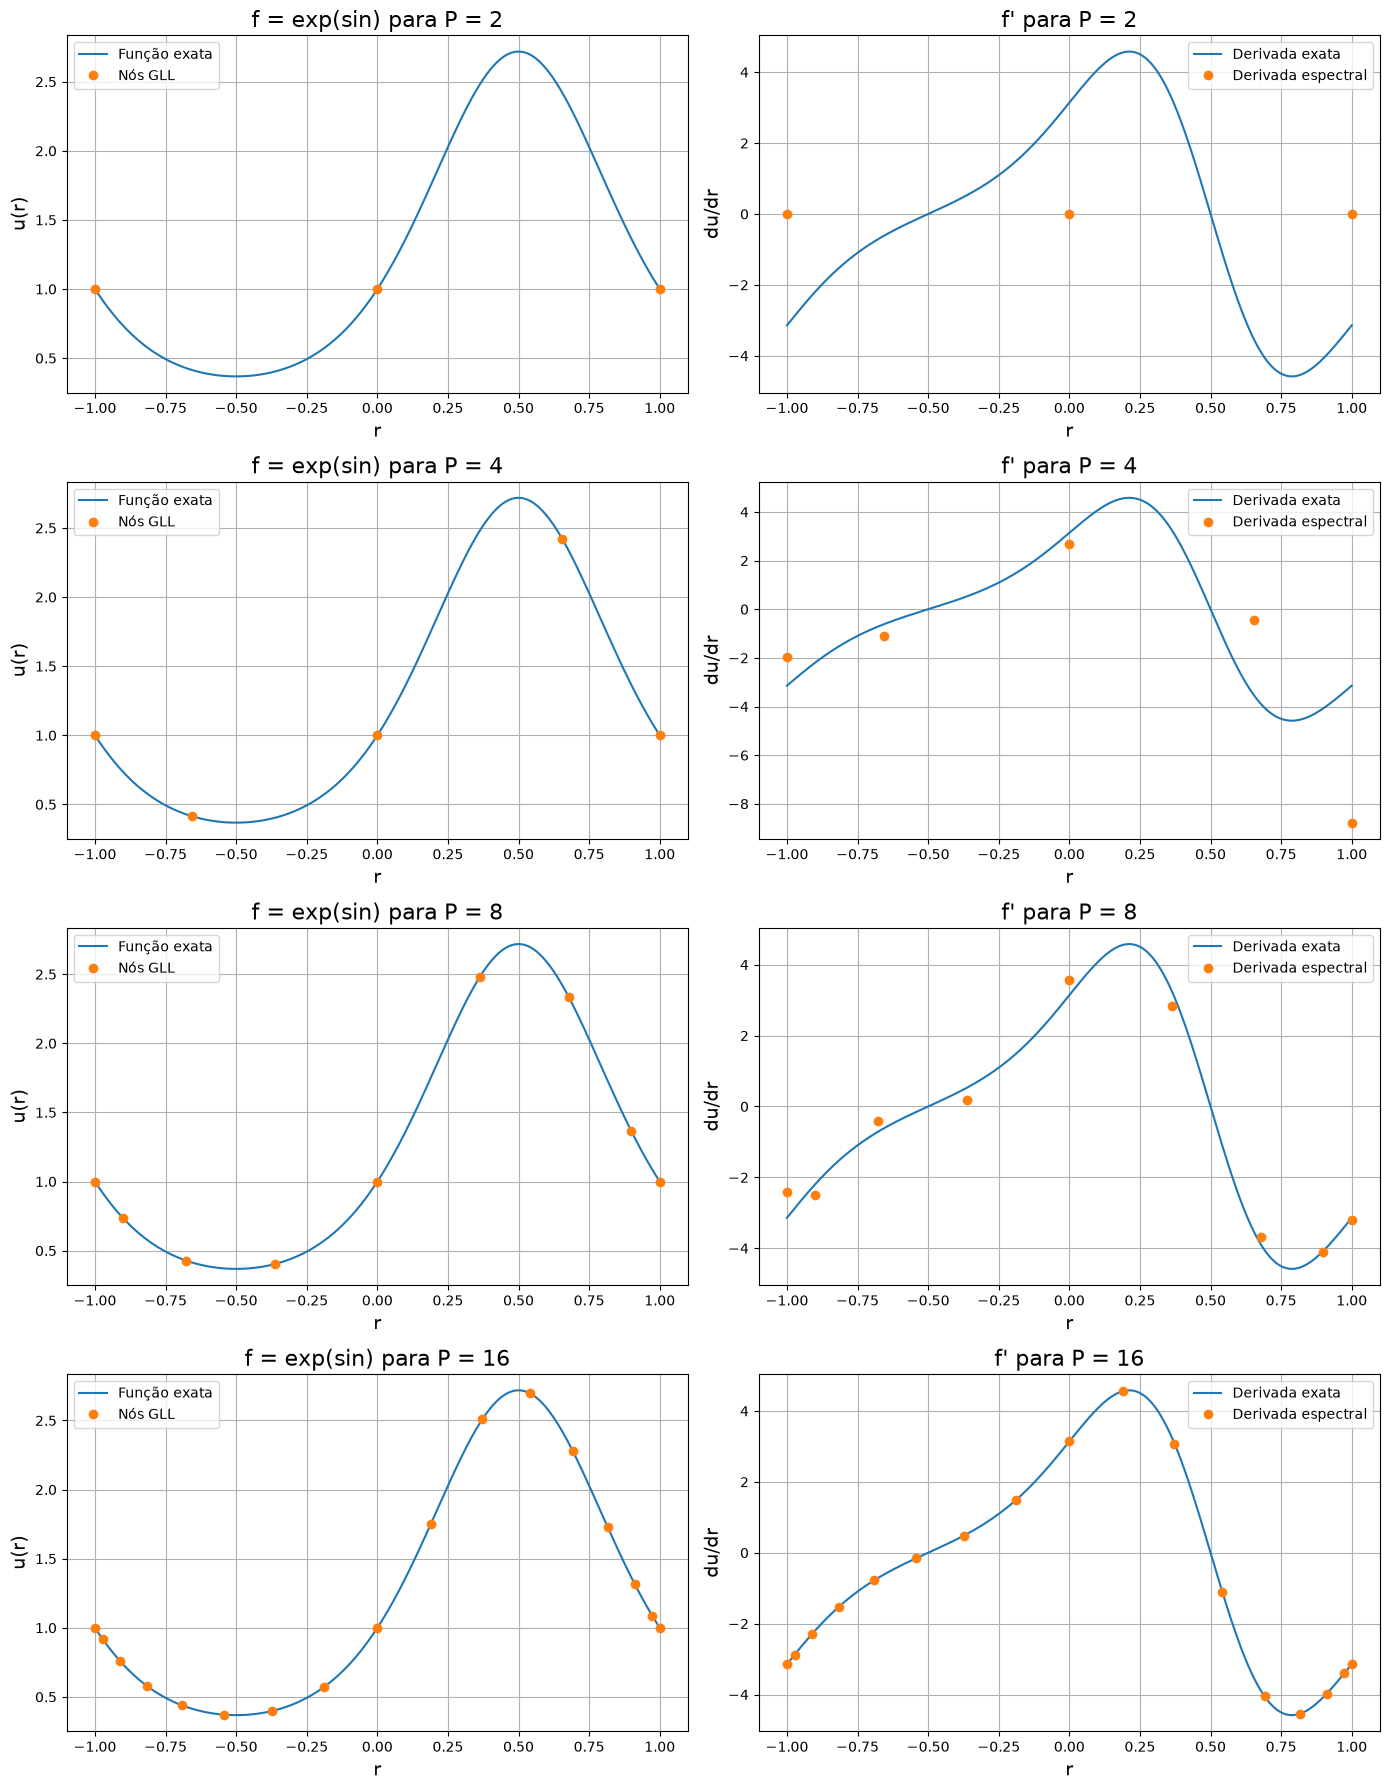

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# LISTA DE CASOS PARA TESTE
# ==========================================================
cases = {
    "sin": (
        np.sin,
        np.cos
    ),
    "cos": (
        np.cos,
        lambda x: -np.sin(x)
    ),
    "exp": (
        np.exp,
        np.exp
    ),
    "exp*sin": (
        lambda x: np.exp(x)*np.sin(x),
        lambda x: np.exp(x)*(np.sin(x)+np.cos(x))
    ),
    "exp(sin)": (
    lambda x: np.exp(np.sin(np.pi*x)),
    lambda x: np.pi*np.cos(np.pi*x)*np.exp(np.sin(np.pi*x)),
    ),
}

# ==========================================================
# CASO SELECIONADO
caso = "exp(sin)"
f, df = cases[caso]
q_type='GLL'        # Explicitando a Quadratura
# ==========================================================
# Valores de P para comparação (grau do polinomio)
P_values = [2, 4, 8, 16]        # até quatro valores

fig, axes = plt.subplots(len(P_values), 2,
                         figsize=(14, 4.5*len(P_values)))

for k, P in enumerate(P_values):
    if q_type == 'GL':
        p_quad = 2*P+1
    else:
        p_quad = 2*P-1

    r , wi = jacobi_gauss_quad(p_quad, quad_type=q_type)
    Dr = DMatrix1D(r,len(r),quad_type=q_type)               # Matriz de diferenciação

    # Solução numérica
    u = f(r)
    du_num = Dr @ u

    # Solução exata
    xx = np.linspace(-1,1,500)
    u_exact = f(xx)
    du_exact = df(xx)

    # Subplot da função
    ax = axes[k,0]
    ax.plot(xx,u_exact,label='Função exata')
    rotulo = 'Nós ' + q_type
    ax.plot(r,u,'o',label=rotulo)
    ax.set_title(f'f = {caso} para P = {P}',fontsize=16)
    ax.set_xlabel('r',fontsize=14)
    ax.set_ylabel('u(r)',fontsize=14)
    ax.grid(True)
    ax.legend()
    # if k == 0:
    #     ax.legend()

    # Subplot da derivada
    ax = axes[k,1]
    ax.plot(xx,du_exact,label='Derivada exata')
    ax.plot(r,du_num,'o',label='Derivada espectral')
    ax.set_title(f"f' para P = {P}",fontsize=16)
    ax.set_xlabel('r',fontsize=14)
    ax.set_ylabel("du/dr",fontsize=14)
    ax.grid(True)
    ax.legend()
    # if k == 0:
    #     ax.legend()

plt.tight_layout()
plt.show()

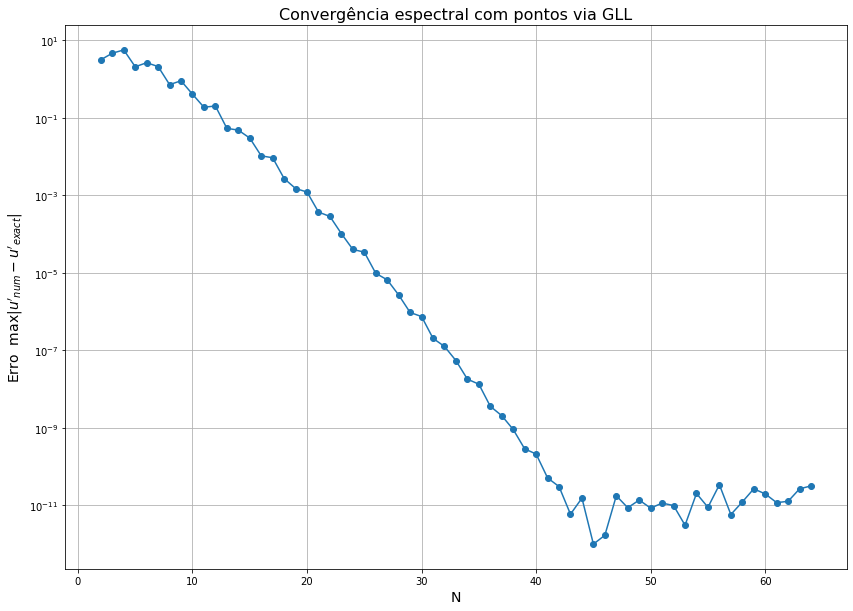

In [53]:
# ==========================================================
# Curva de convergência
# ==========================================================
Ps = np.arange(2,65)   # Grau dos polinomios a serem usados
erro = []

# CASO SELECIONADO
caso = "exp(sin)"
f, df = cases[caso]
q_type = 'GLL'

for P in Ps:
    if q_type == 'GL':
        p_quad = 2*P+1
    else:
        p_quad = 2*P-1
    r , wi = jacobi_gauss_quad(p_quad, quad_type=q_type)
    Dr = DMatrix1D(r,len(r),quad_type=q_type)
    u = f(r)
    du_num = Dr @ u
    du_exact = df(r)
    erro.append(np.max(np.abs(du_num-du_exact)))

plt.figure(figsize=(14,10))
plt.semilogy(Ps,erro,'o-')
plt.xlabel('N',fontsize=14)
plt.ylabel(r"Erro  $\max|u'_{num} - u'_{exact}|$",fontsize=14)
plt.title(f"Convergência espectral com pontos via {q_type}",fontsize=16)
plt.grid(True,which='both')
plt.show()

## Uso da Matriz de Diferenciação para outros Dominios

Vamos exemplificar como fica o uso no caso de querermos avaliar o dominio fisico

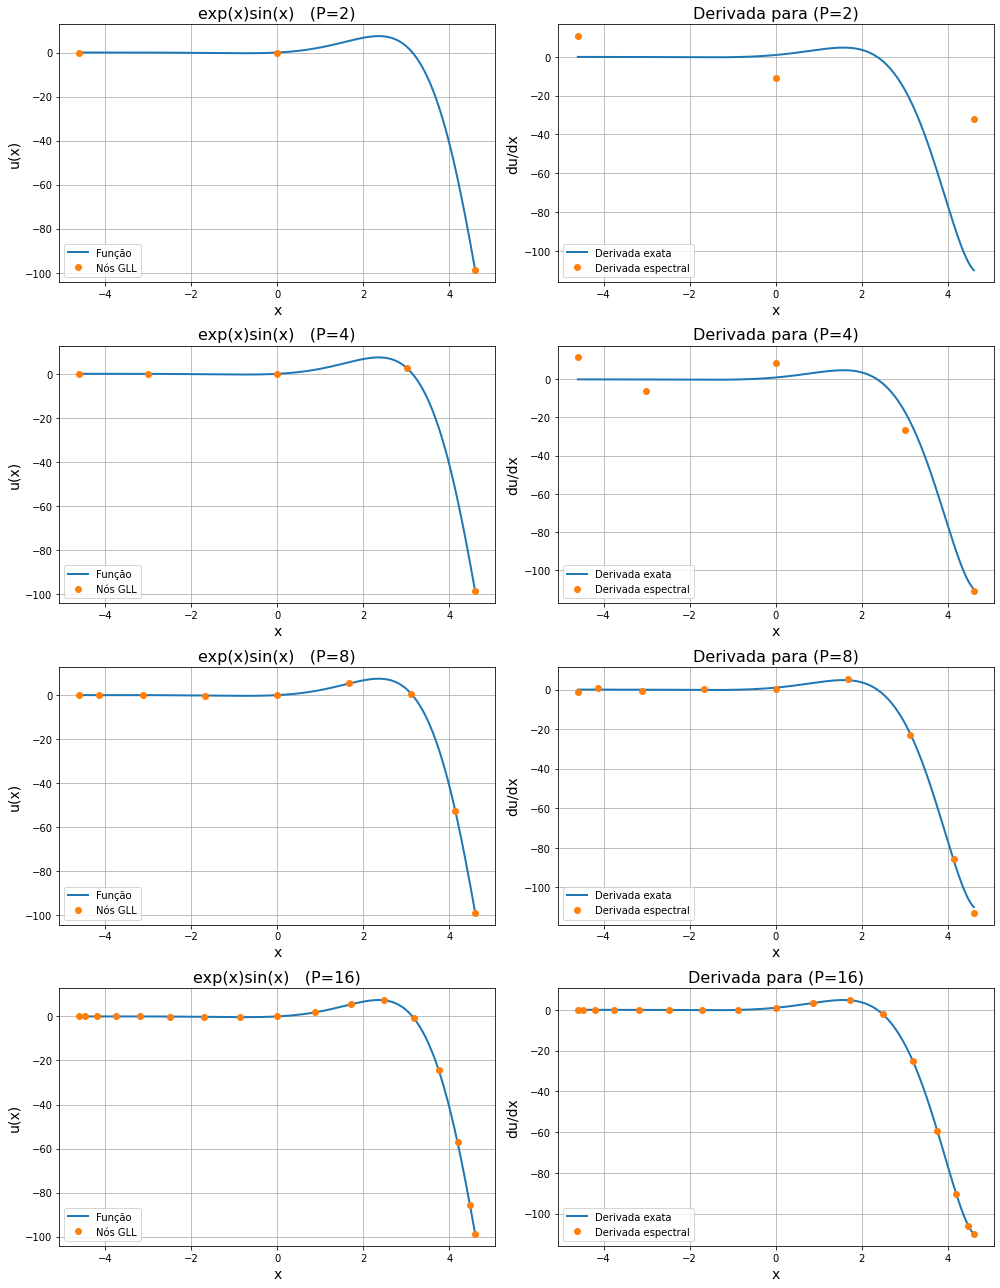

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# LISTA DE CASOS PARA TESTE
# Formato:
# nome : (função, derivada, (a,b))
# ==========================================================
cases2 = {
    "sin(x)": (
        np.sin,
        np.cos,
        (-np.pi, np.pi)
    ),

    "cos(x)": (
        np.cos,
        lambda x: -np.sin(x),
        (-np.pi, np.pi)
    ),

    "exp(x)sin(x)": (
        lambda x: np.exp(x)*np.sin(x),
        lambda x: np.exp(x)*(np.sin(x)+np.cos(x)),
        (-4.6,4.6)
    ),

    "x^3-2x+1": (
        lambda x: x**3 - 2*x + 1,
        lambda x: 3*x**2 - 2,
        (-2,2)
    ),

    "Runge": (
        lambda x: 1/(1+25*x**2),
        lambda x: -50*x/(1+25*x**2)**2,
        (-1,1)
    )
}

# CASO ESCOLHIDO
caso = "exp(x)sin(x)"
f, df, dominio = cases2[caso]
a, b = dominio

# Valores de P
P_values = [2,4,8,16]
#P_values = [4,16,20,30]

# Quadratura escolhida
quad_tipo="GLL"

fig, axes = plt.subplots(
    len(P_values),2,figsize=(14,4.5*len(P_values))
)

for k, P in enumerate(P_values):
    if q_type == 'GL':
        p_quad = 2*P+1
    else:
        p_quad = 2*P-1
    
    r, wi = jacobi_gauss_quad(p_quad,quad_type=quad_tipo)  # Pontos no elemento de referência
    x = (a+b)/2 + (b-a)/2*r                                # Mapeamento para o domínio físico
    Dr = DMatrix1D(r,len(r),quad_type=quad_tipo)           # Matriz de diferenciação no elemento de referência
    u = f(x)                                               # Valores da função
    du_num = (2/(b-a))*(Dr @ u)                            # Derivada espectral (regra da cadeia)

    # Solução exata
    xx = np.linspace(a,b,600)
    u_exact = f(xx)
    du_exact = df(xx)

    # Plot da Funcao
    ax = axes[k,0]
    ax.plot(xx,u_exact, lw=2, label="Função")
    rotulo = "Nós " + quad_tipo
    ax.plot(x,u,'o',ms=6,label=rotulo)
    ax.set_title(f"{caso}   (P={P})", fontsize = 16)
    ax.set_xlabel("x", fontsize = 14)
    ax.set_ylabel("u(x)", fontsize = 14)
    ax.grid(True)
    ax.legend()
    # if k == 0:
    #     ax.legend()

    # Plot da Derivada
    ax = axes[k,1]
    ax.plot(xx,du_exact, lw=2, label="Derivada exata")
    ax.plot(x,du_num, 'o', ms=6, label="Derivada espectral")
    ax.set_title(f"Derivada para (P={P})", fontsize = 16)
    ax.set_xlabel("x", fontsize = 14)
    ax.set_ylabel("du/dx", fontsize = 14)
    ax.grid(True)
    ax.legend()
    # if k == 0:
    #     ax.legend()

plt.tight_layout()
plt.show()